# Scientific Machine Learning HW 1: Support Vector Machines and Phase Transition of Ising Model

In [1]:
import numpy as np

try:
    from sklearnex import patch_sklearn
    patch_sklearn()
except:
    print("Intel® Extension for Scikit-learn* not installed.")

from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import pickle

from sklearn.linear_model import LogisticRegressionCV
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

c:\Users\danie\miniconda3\envs\default\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Extension for Scikit-learn* enabled (https://github.com/uxlfoundation/scikit-learn-intelex)


## Prepare Data

In [2]:
# The data consists of 16 * 10000 samples taken in T = {0.25, 0.5, ..., 4.}.
# Each sample consists of spins in a 40 * 40 lattice.
temps = np.repeat(np.linspace(0.25, 4., 16), 10000)
T_c = 2 / np.log(1 + np.sqrt(2))
# The first 9 * 10000 samples are ordered (label 1).
# The remaining 7 * 10000 samples are disordered (label 0).
data_file_name = "Ising2DFM_reSample_L40_T=All.pkl"
label_file_name = "Ising2DFM_reSample_L40_T=All_labels.pkl"

with open(data_file_name, "rb") as pickle_file:
    data = pickle.load(pickle_file)
data = np.unpackbits(data).reshape(-1, 1600).astype(np.int32)
data[np.where(data==0)] = -1

# Label is 1 for ordered states and 0 for disordered states
with open(label_file_name, "rb") as pickle_file:
    labels = pickle.load(pickle_file).astype(np.int32)

print("Data shape:", data.shape)
print("Labels:", np.unique(labels))

Data shape: (160000, 1600)
Labels: [0 1]


In [3]:
# 75% train, 25% test
data_train, data_test, labels_train, labels_test, temps_train, temps_test = train_test_split(data, labels, temps, stratify = temps)

In [4]:
scorers = ["accuracy", "precision", "recall", "f1"]
scoring_functions = [accuracy_score,
                     lambda y_true, y_pred: precision_score(y_true, y_pred, zero_division = np.nan),
                     lambda y_true, y_pred: recall_score(y_true, y_pred, zero_division = np.nan),
                     lambda y_true, y_pred: f1_score(y_true, y_pred, zero_division = np.nan)]

## Logistic Regression

In [5]:
lr_models = [LogisticRegressionCV(l1_ratios = (0,), scoring = scorer, max_iter = 1000,
                                  cv = StratifiedKFold(n_splits = 5, shuffle = True), n_jobs = -2,
                                  use_legacy_attributes = False)
             for scorer in scorers]

In [6]:
# Takes about 4 minutes on my laptop
for lr_model in tqdm(lr_models):
    lr_model.fit(data_train, labels_train)

  0%|          | 0/4 [00:00<?, ?it/s]

In [7]:
lr_scores = np.zeros(len(scorers))
lr_scores_temps = np.zeros((len(scorers), 16))

for i, lr_model in enumerate(tqdm(lr_models)):
    print("Metric: {}".format(lr_model.scoring))
    lr_scores[i] = lr_model.score(data_test, labels_test)
    print("Overall {}: {:.4f}".format(lr_model.scoring, lr_scores[i]))
    for j in range(16):
        temp = 0.25 * (j + 1)
        if lr_model.scoring == "recall" and temp > T_c:
            # Recall is ill-defined when there are no positive samples
            lr_scores_temps[i, j] = np.nan
        else:
            lr_scores_temps[i, j] = lr_model.score(data_test[temps_test == temp], labels_test[temps_test == temp])
    if lr_model.scoring == "accuracy":
        print("Best {}: {:.4f} at T = {}".format(lr_model.scoring, np.max(lr_scores_temps[i]),
                                                 0.25 * (np.argmax(lr_scores_temps[i]) + 1)))
        print("Worst {}: {:.4f} at T = {}".format(lr_model.scoring, np.min(lr_scores_temps[i]),
                                                  0.25 * (np.argmin(lr_scores_temps[i]) + 1)))
    else:
        # Precision and F1 are trivially 0 when there are no positive samples
        print("Best {}: {:.4f} at T = {}".format(lr_model.scoring, np.max(lr_scores_temps[i, :9]),
                                                 0.25 * (np.argmax(lr_scores_temps[i, :9]) + 1)))
        print("Worst {}: {:.4f} at T = {}".format(lr_model.scoring, np.min(lr_scores_temps[i, :9]),
                                                  0.25 * (np.argmin(lr_scores_temps[i, :9]) + 1)))
    print()

  0%|          | 0/4 [00:00<?, ?it/s]

Metric: accuracy
Overall accuracy: 0.6516
Best accuracy: 1.0000 at T = 0.25
Worst accuracy: 0.2036 at T = 2.5

Metric: precision
Overall precision: 0.6211
Best precision: 1.0000 at T = 0.25
Worst precision: 1.0000 at T = 0.25

Metric: recall
Overall recall: 0.9963
Best recall: 1.0000 at T = 0.25
Worst recall: 0.9696 at T = 2.25

Metric: f1
Overall f1: 0.7593
Best f1: 1.0000 at T = 0.25
Worst f1: 0.9238 at T = 2.25



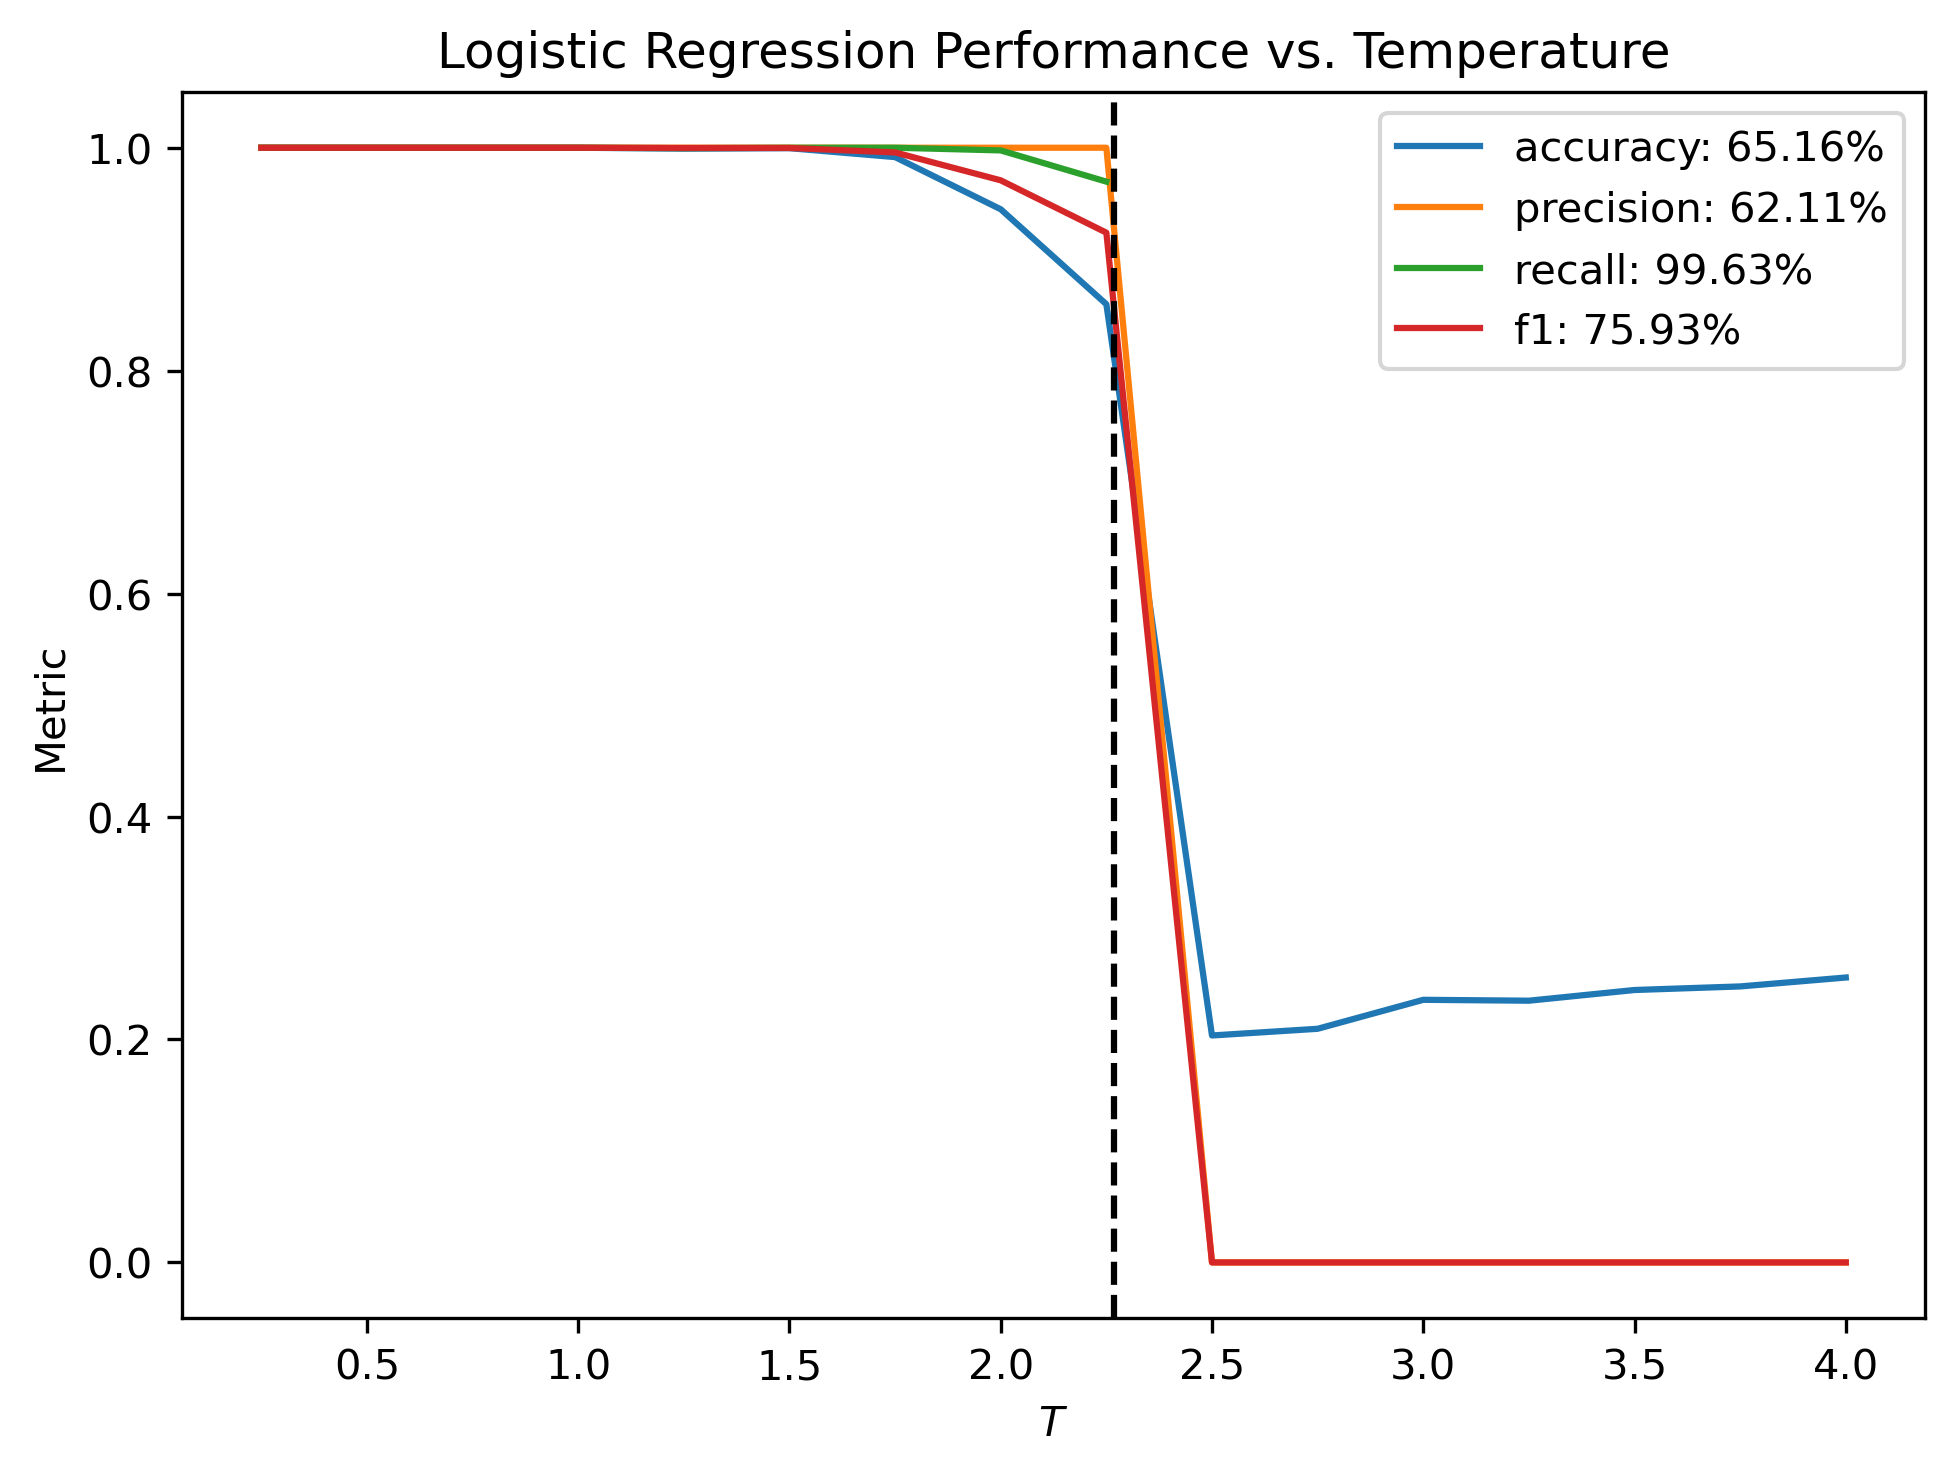

In [8]:
plt.figure(dpi = 300, layout = "constrained")
for i, scorer in enumerate(scorers):
    plt.plot(np.linspace(0.25, 4., 16), lr_scores_temps[i], label = "{}: {:.2%}".format(scorer, lr_scores[i]))
plt.axvline(T_c, color = "k", linestyle = "--")
plt.xlabel(r"$T$")
plt.ylabel("Metric")
plt.title("Logistic Regression Performance vs. Temperature")
plt.legend()
plt.savefig("logistic.pdf")

## SVM

In [9]:
linear_svm = make_pipeline(StandardScaler(), LinearSVC(), verbose = True)
svm = make_pipeline(StandardScaler(), SVC(), verbose = True)

In [10]:
# Takes about 1 minute on my laptop
linear_svm.fit(data_train, labels_train)

[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   5.6s
[Pipeline] ......... (step 2 of 2) Processing linearsvc, total=  49.2s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('linearsvc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",True
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [11]:
# Takes about 1.5 minutes on my laptop
svm.fit(data_train, labels_train)

[Pipeline] .... (step 1 of 2) Processing standardscaler, total=   3.7s
[Pipeline] ............... (step 2 of 2) Processing svc, total= 1.1min


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",True
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [12]:
linear_svm_pred = linear_svm.predict(data_test)
svm_pred = svm.predict(data_test)

In [13]:
linear_svm_scores = np.zeros(len(scorers))
linear_svm_scores_temps = np.zeros((len(scorers), 16))

for i, scoring in enumerate(tqdm(scorers)):
    print("Metric: {}".format(scoring))
    linear_svm_scores[i] = scoring_functions[i](labels_test, linear_svm_pred)
    print("Overall {}: {:.4f}".format(scoring, linear_svm_scores[i]))
    for j in range(16):
        temp = 0.25 * (j + 1)
        linear_svm_scores_temps[i, j] = scoring_functions[i](labels_test[temps_test == temp], linear_svm_pred[temps_test == temp])
    if scoring == "accuracy":
        print("Best {}: {:.4f} at T = {}".format(scoring, np.nanmax(linear_svm_scores_temps[i]),
                                                 0.25 * (np.nanargmax(linear_svm_scores_temps[i]) + 1)))
        print("Worst {}: {:.4f} at T = {}".format(scoring, np.nanmin(linear_svm_scores_temps[i]),
                                                  0.25 * (np.nanargmin(linear_svm_scores_temps[i]) + 1)))
    else:
        print("Best {}: {:.4f} at T = {}".format(scoring, np.nanmax(linear_svm_scores_temps[i, :9]),
                                                 0.25 * (np.nanargmax(linear_svm_scores_temps[i, :9]) + 1)))
        print("Worst {}: {:.4f} at T = {}".format(scoring, np.nanmin(linear_svm_scores_temps[i, :9]),
                                                  0.25 * (np.nanargmin(linear_svm_scores_temps[i, :9]) + 1)))
    print()

  0%|          | 0/4 [00:00<?, ?it/s]

Metric: accuracy
Overall accuracy: 0.6506
Best accuracy: 1.0000 at T = 0.25
Worst accuracy: 0.2020 at T = 2.5

Metric: precision
Overall precision: 0.6201
Best precision: 1.0000 at T = 0.25
Worst precision: 1.0000 at T = 0.25

Metric: recall
Overall recall: 0.9779
Best recall: 1.0000 at T = 0.25
Worst recall: 0.8624 at T = 2.25

Metric: f1
Overall f1: 0.7590
Best f1: 1.0000 at T = 0.25
Worst f1: 0.9261 at T = 2.25



In [14]:
svm_scores = np.zeros(len(scorers))
svm_scores_temps = np.zeros((len(scorers), 16))

for i, scoring in enumerate(tqdm(scorers)):
    print("Metric: {}".format(scoring))
    svm_scores[i] = scoring_functions[i](labels_test, svm_pred)
    print("Overall {}: {:.4f}".format(scoring, svm_scores[i]))
    for j in range(16):
        temp = 0.25 * (j + 1)
        svm_scores_temps[i, j] = scoring_functions[i](labels_test[temps_test == temp], svm_pred[temps_test == temp])
    if scoring == "accuracy":
        print("Best {}: {:.4f} at T = {}".format(scoring, np.nanmax(svm_scores_temps[i]),
                                                 0.25 * (np.nanargmax(svm_scores_temps[i]) + 1)))
        print("Worst {}: {:.4f} at T = {}".format(scoring, np.nanmin(svm_scores_temps[i]),
                                                  0.25 * (np.nanargmin(svm_scores_temps[i]) + 1)))
    else:
        print("Best {}: {:.4f} at T = {}".format(scoring, np.nanmax(svm_scores_temps[i, :9]),
                                                 0.25 * (np.nanargmax(svm_scores_temps[i, :9]) + 1)))
        print("Worst {}: {:.4f} at T = {}".format(scoring, np.nanmin(svm_scores_temps[i, :9]),
                                                  0.25 * (np.nanargmin(svm_scores_temps[i, :9]) + 1)))
    print()

  0%|          | 0/4 [00:00<?, ?it/s]

Metric: accuracy
Overall accuracy: 0.9964
Best accuracy: 1.0000 at T = 0.25
Worst accuracy: 0.9480 at T = 2.25

Metric: precision
Overall precision: 0.9993
Best precision: 1.0000 at T = 0.25
Worst precision: 1.0000 at T = 0.25

Metric: recall
Overall recall: 0.9942
Best recall: 1.0000 at T = 0.25
Worst recall: 0.9480 at T = 2.25

Metric: f1
Overall f1: 0.9968
Best f1: 1.0000 at T = 0.25
Worst f1: 0.9733 at T = 2.25



  0%|          | 0/4 [00:00<?, ?it/s]

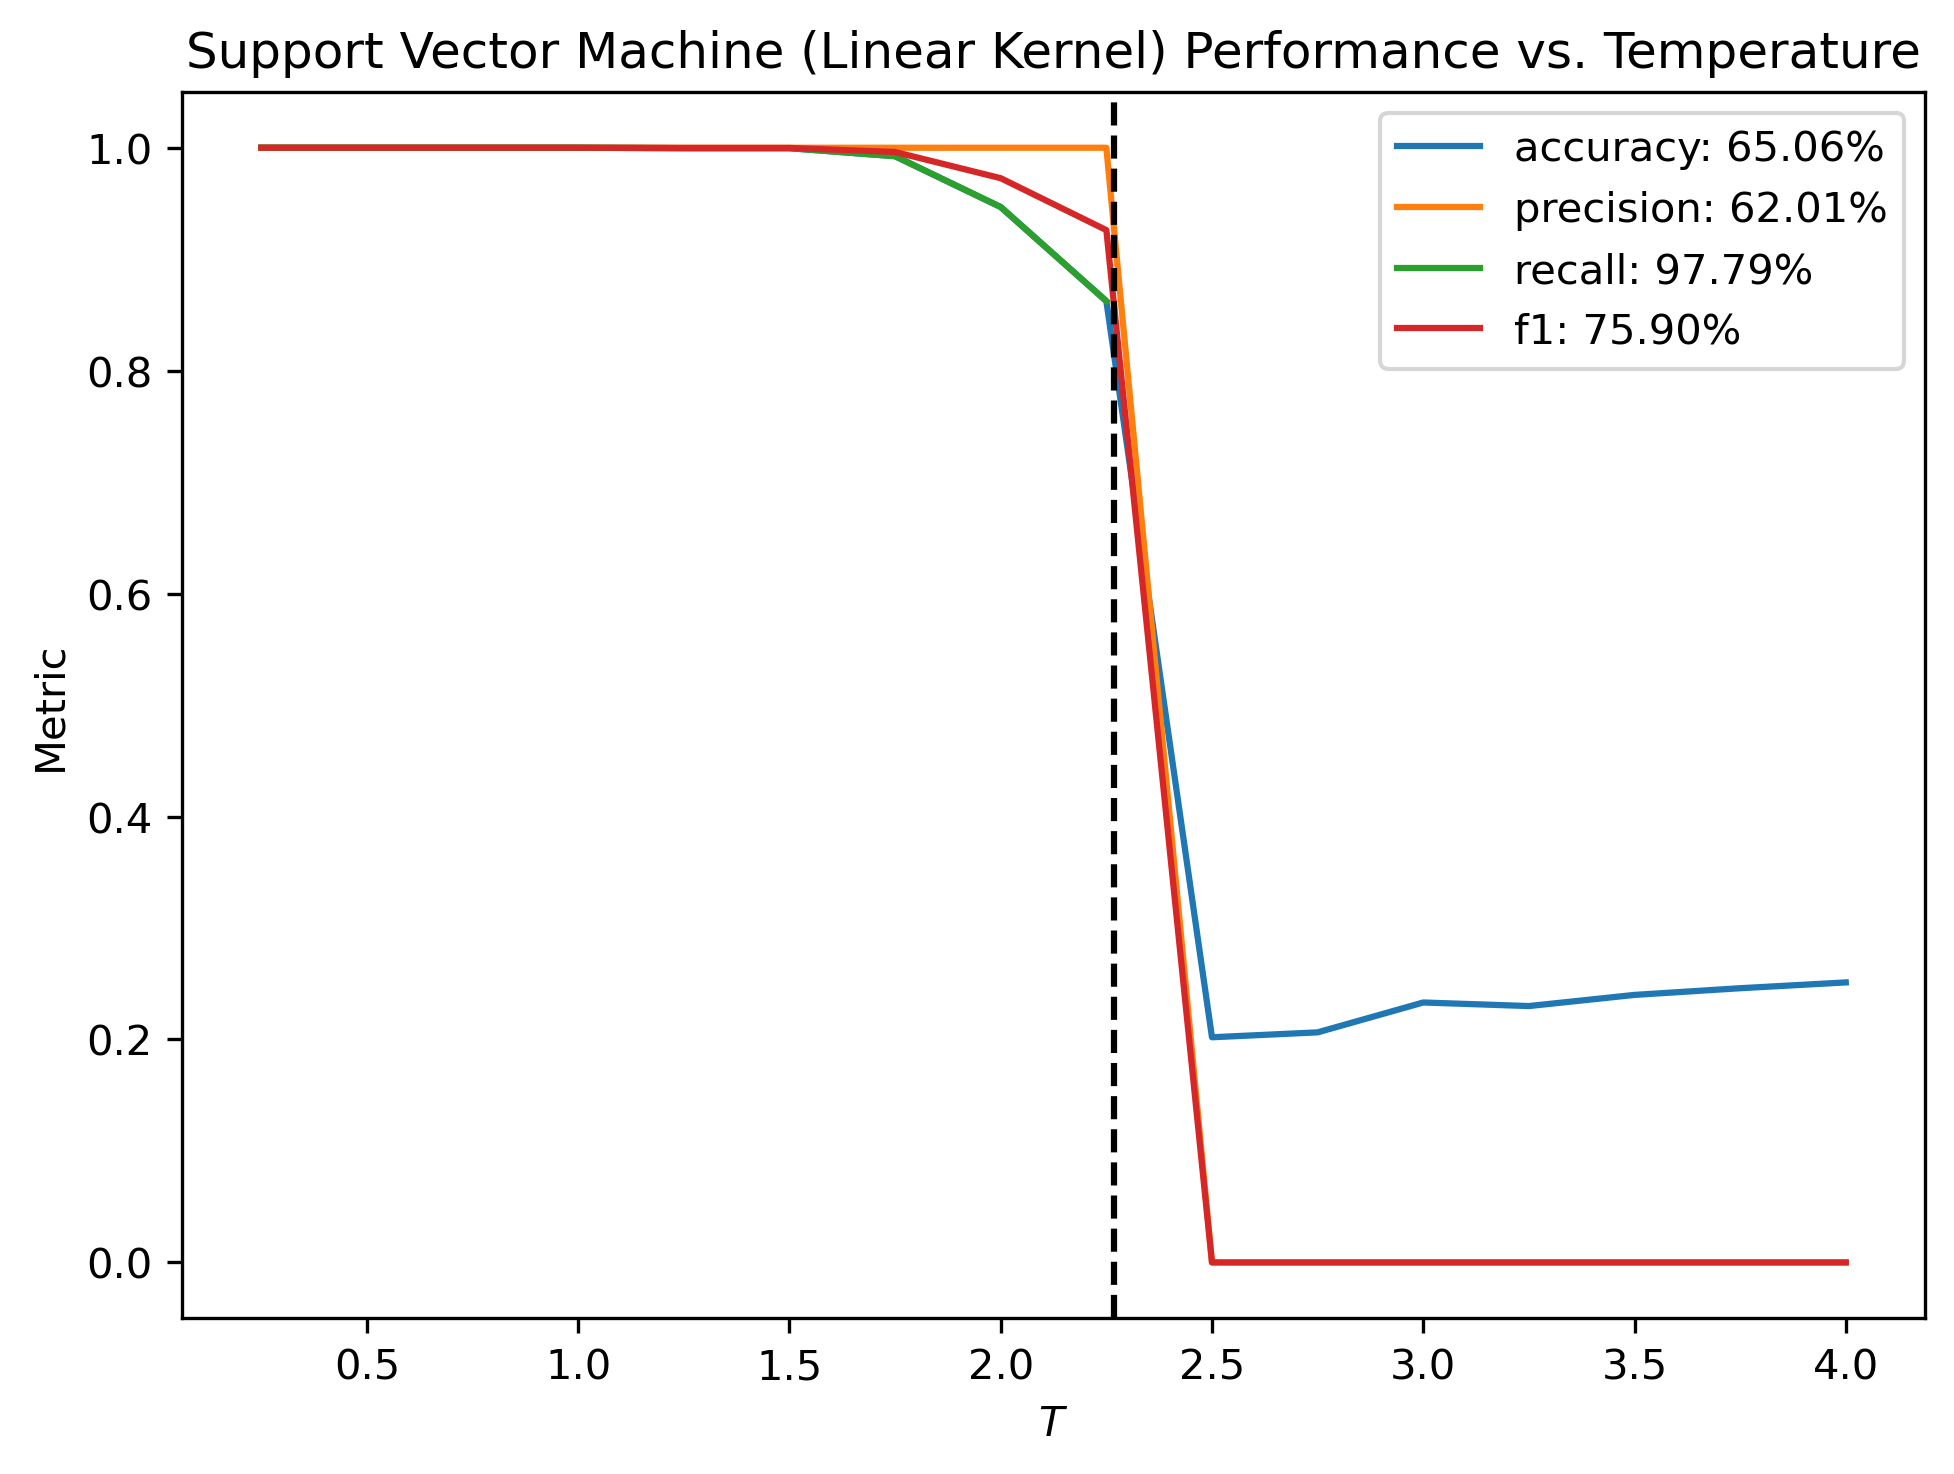

In [15]:
plt.figure(dpi = 300, layout = "constrained")
for i, scorer in enumerate(tqdm(scorers)):
    plt.plot(np.linspace(0.25, 4., 16), linear_svm_scores_temps[i], label = "{}: {:.2%}".format(scorer, linear_svm_scores[i]))
plt.axvline(T_c, color = "k", linestyle = "--")
plt.xlabel(r"$T$")
plt.ylabel("Metric")
plt.title("Support Vector Machine (Linear Kernel) Performance vs. Temperature")
plt.legend()
plt.savefig("linear_svm.pdf")

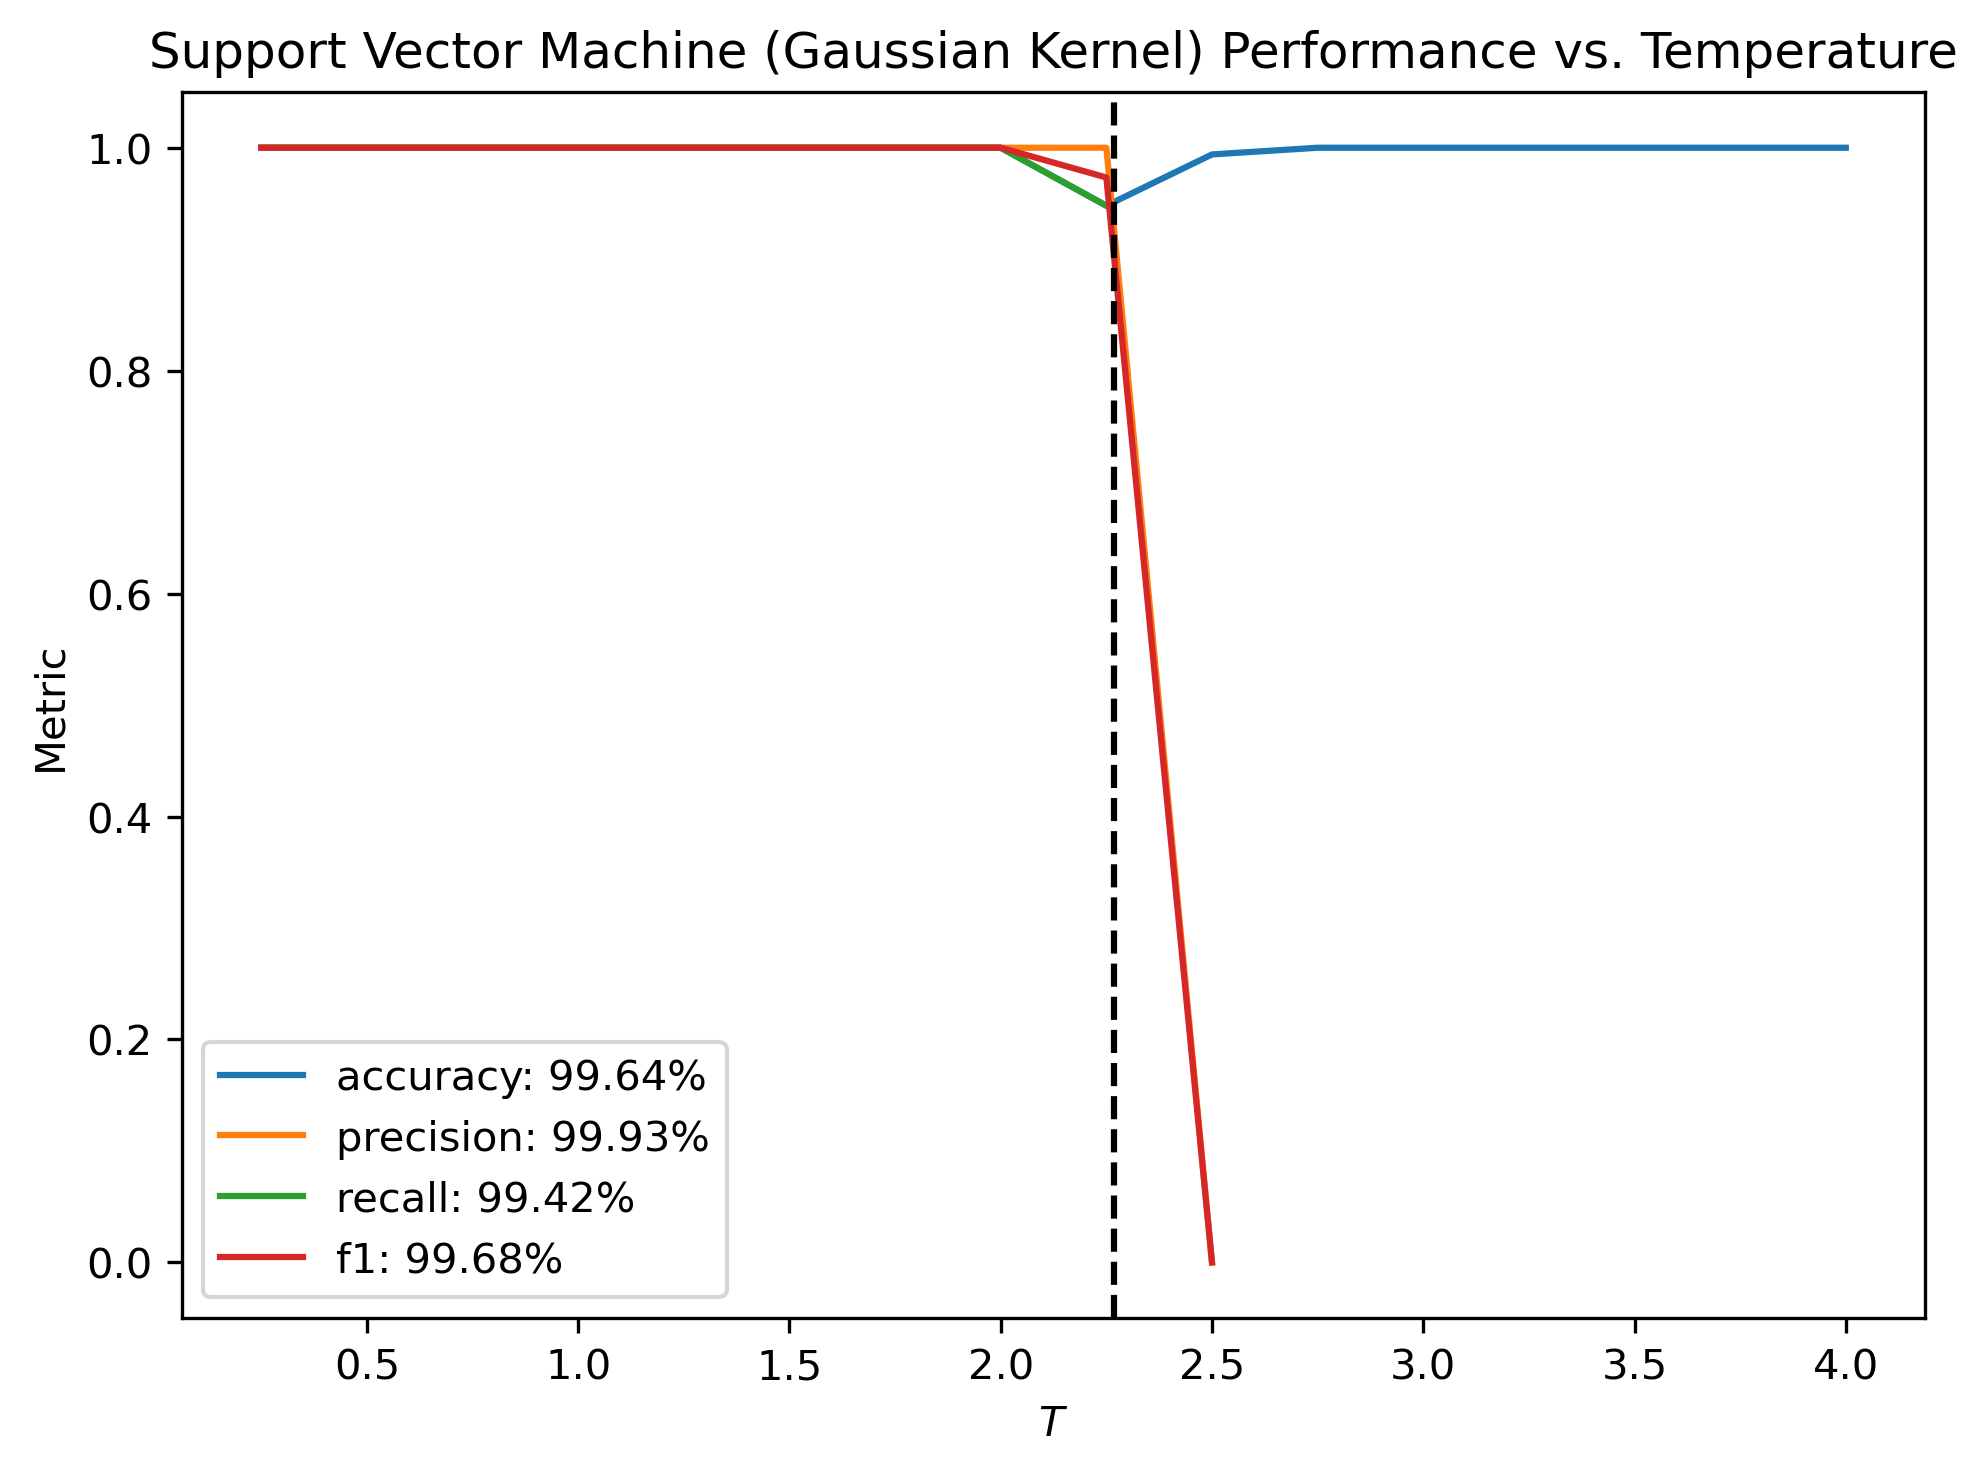

In [16]:
plt.figure(dpi = 300, layout = "constrained")
for i, scorer in enumerate(scorers):
    plt.plot(np.linspace(0.25, 4., 16), svm_scores_temps[i], label = "{}: {:.2%}".format(scorer, svm_scores[i]))
plt.axvline(T_c, color = "k", linestyle = "--")
plt.xlabel(r"$T$")
plt.ylabel("Metric")
plt.title("Support Vector Machine (Gaussian Kernel) Performance vs. Temperature")
plt.legend()
plt.savefig("svm.pdf")

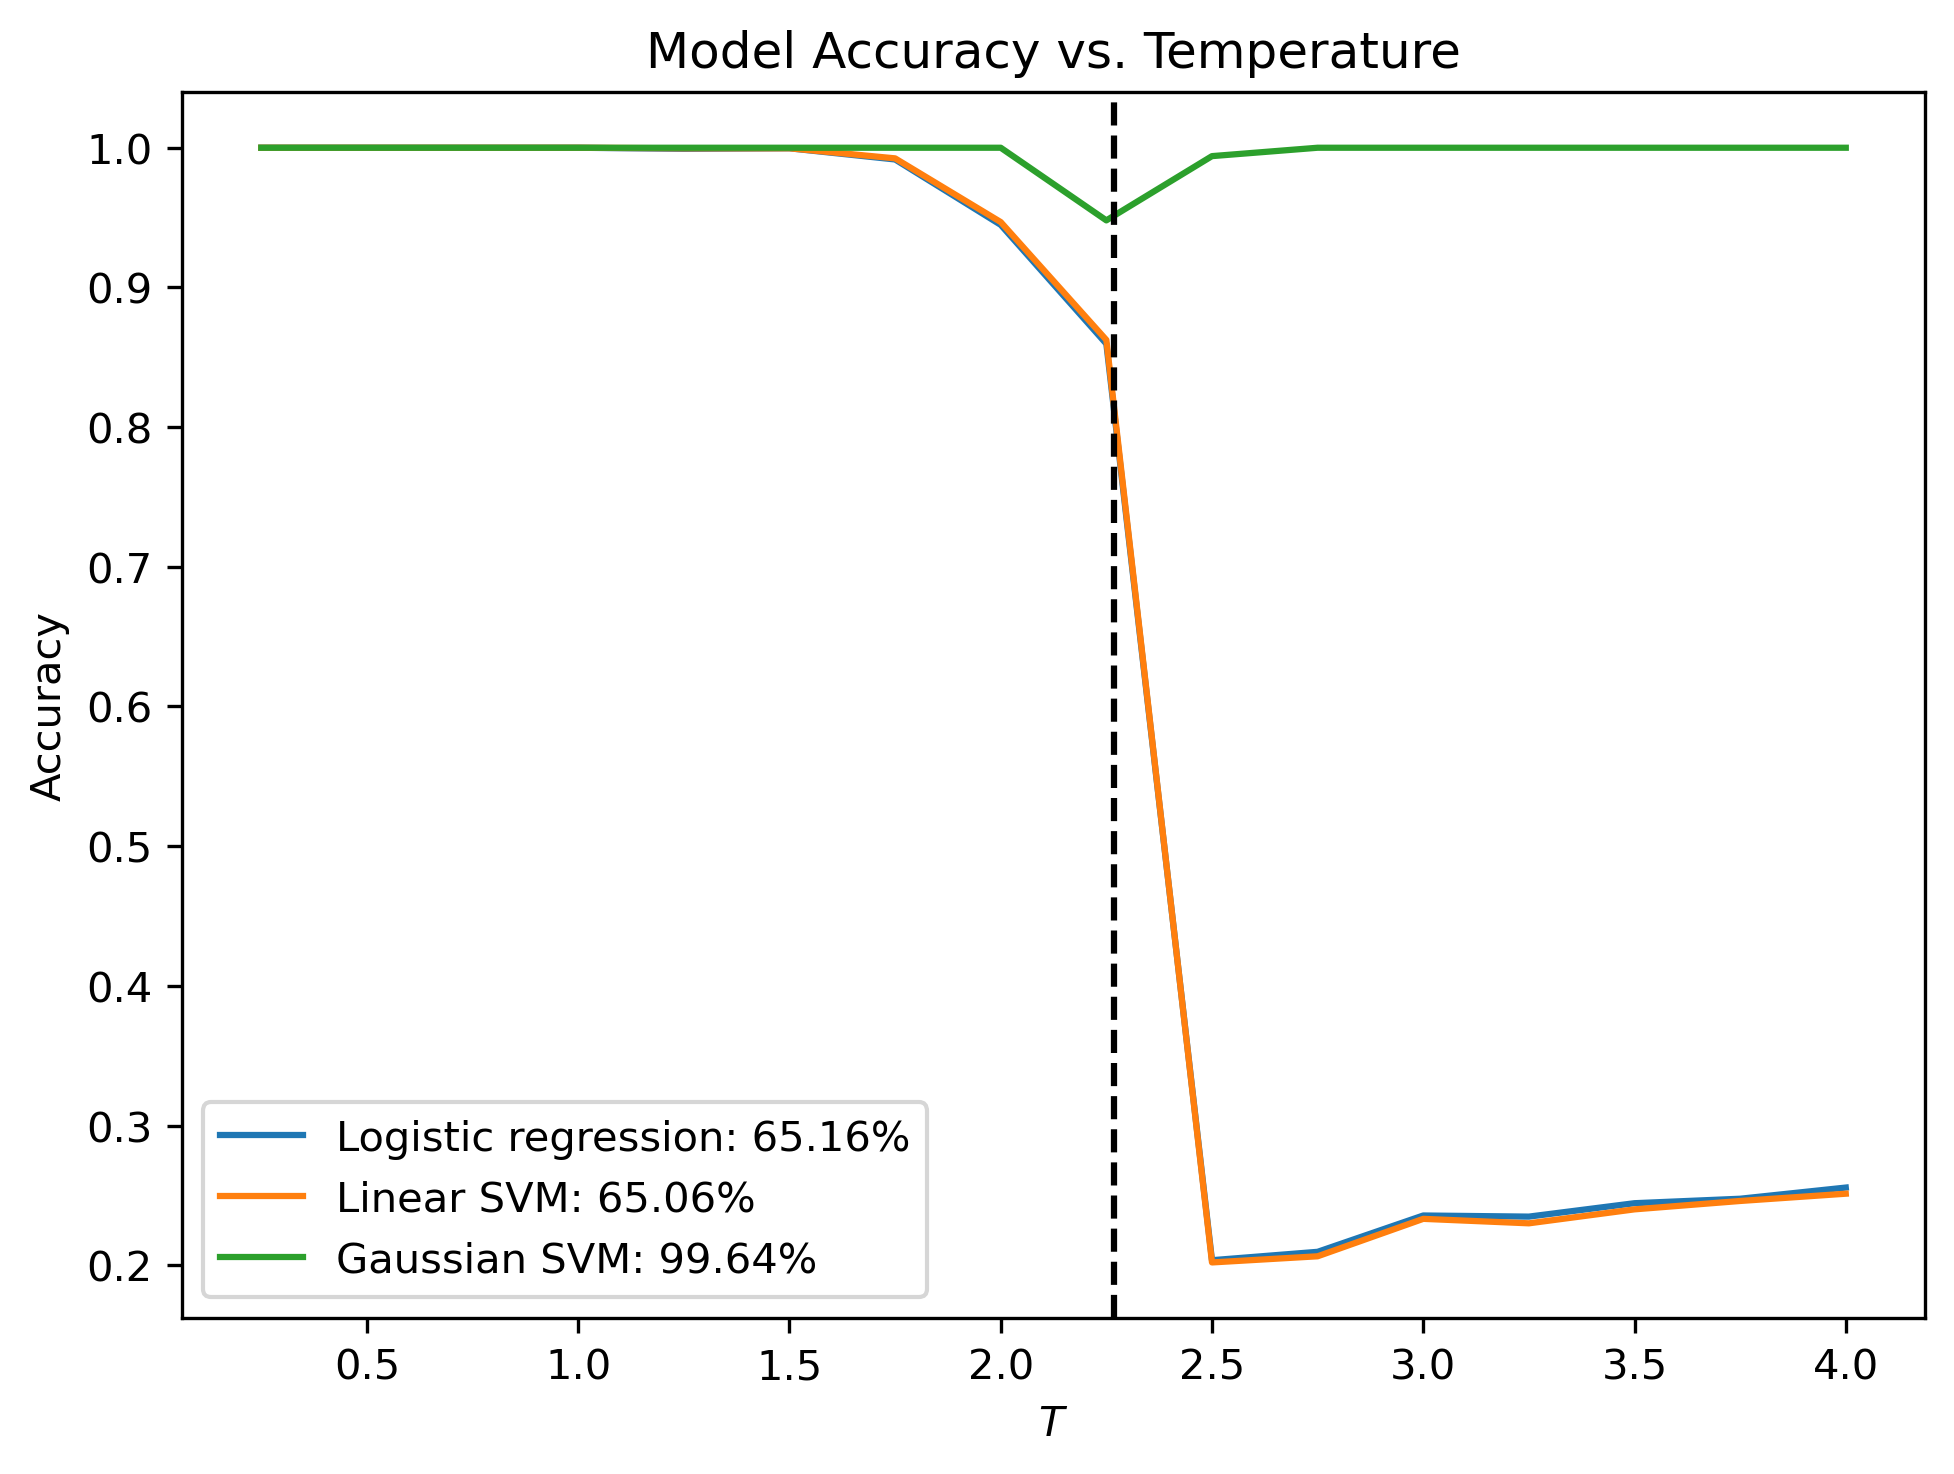

In [17]:
plt.figure(dpi = 300, layout = "constrained")
plt.plot(np.linspace(0.25, 4., 16), lr_scores_temps[0], label = "Logistic regression: {:.2%}".format(lr_scores[0]))
plt.plot(np.linspace(0.25, 4., 16), linear_svm_scores_temps[0], label = "Linear SVM: {:.2%}".format(linear_svm_scores[0]))
plt.plot(np.linspace(0.25, 4., 16), svm_scores_temps[0], label = "Gaussian SVM: {:.2%}".format(svm_scores[0]))
plt.axvline(T_c, color = "k", linestyle = "--")
plt.xlabel(r"$T$")
plt.ylabel("Accuracy")
plt.title("Model Accuracy vs. Temperature")
plt.legend()
plt.savefig("accuracy.pdf")